In [1]:
!pip install sentence-transformers seaborn matplotlib

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
sentences = [
    # Cricket (4 sentences)
    "The captain set an aggressive field during the match",
    "The batsman hit a six over long-on",
    "The bowler bowled a perfect spin delivery",
    "The team celebrated their victory on the ground",

    # Cooking (3 sentences)
    "Chop the onions finely before adding them to the pan",
    "Bake the cake at 180 degrees for 30 minutes",
    "Mix all the ingredients thoroughly to form a smooth batter",

    # Cybersecurity (3 sentences)
    "Encryption helps secure sensitive information online",
    "Phishing attacks trick users into revealing personal data",
    "Installing antivirus software protects your system from threats"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
similarity_matrix = cosine_similarity(embeddings)

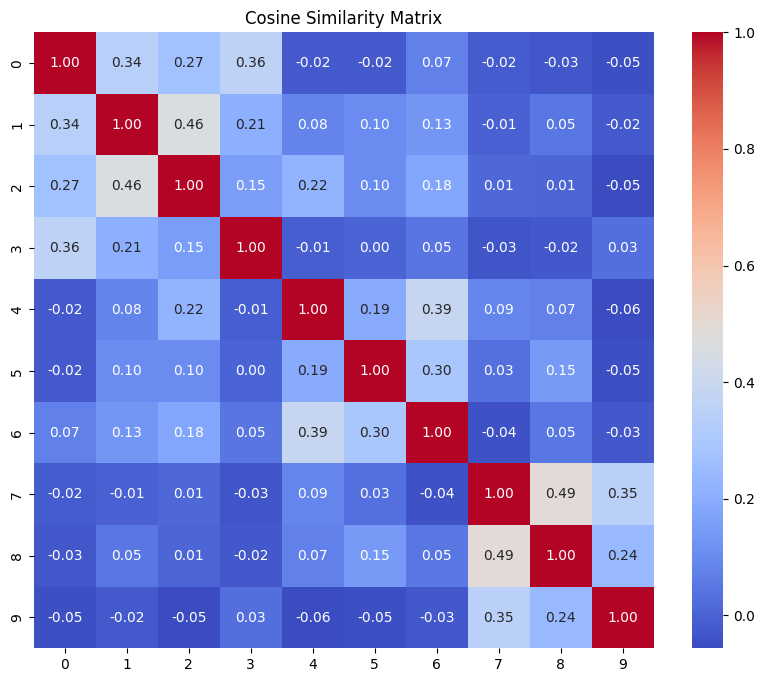

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cosine Similarity Matrix")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

In [8]:
top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print("------")

Sentence: The bowler bowled a perfect spin delivery
Similarity Score: 0.6623
------
Sentence: The batsman hit a six over long-on
Similarity Score: 0.5655
------
